In [ ]:
import pandas as pd
import requests
from typing import Optional

records = []
# creating room = a list containing 3 lists (1 for each room) with items 1. room name, 2. temperature URL, 3. noise URL
rooms = [
        ("BG.West.010", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(1)/Observations?$orderby=phenomenonTime desc", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(6)/Observations?$orderby=phenomenonTime desc"),
        ("BG.West.270", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(7)/Observations?$orderby=phenomenonTime desc", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(12)/Observations?$orderby=phenomenonTime desc"),
        ("01.West.120", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(13)/Observations?$orderby=phenomenonTime desc", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(18)/Observations?$orderby=phenomenonTime desc"),
    ]
temp_records = []
noise_records = []

# fetch ALL paginated observations from server
def fetch_all_observations(url):
    observations = []
    while url:
        try:
            response = requests.get(url)
            response.raise_for_status()
            data = response.json()
            observations.extend(data.get("value", []))
            url = data.get("@iot.nextLink")  # move to next page if available
        except Exception as e:
            print(f"Error fetching from {url}:\n{e}")
            break
    return observations

for room_name, temp_url, noise_url in rooms:
    temp_obs = fetch_all_observations(temp_url)
    noise_obs = fetch_all_observations(noise_url)

    for obs in temp_obs:
        temp_records.append({
            "room_name": room_name,
            "internal_temp": obs.get("result"),
            "temp_unit": "°C",
            "phenomenon_time": obs.get("phenomenonTime")
        })

    for obs in noise_obs:
        noise_records.append({
            "room_name": room_name,
            "noise": obs.get("result"),
            "noise_unit": "db",
            "phenomenon_time": obs.get("phenomenonTime")
        })

# Creating DataFrames
df_temp = pd.DataFrame(temp_records)
df_noise = pd.DataFrame(noise_records)

# cleaning up the DataFrames
df_temp_cleaned = df_temp.drop_duplicates(subset=["room_name", "phenomenon_time"])
df_noise_cleaned = df_noise.drop_duplicates(subset=["room_name", "phenomenon_time"])
# Preview the result
print("Temperature DataFrame (head):")
print(df_temp_cleaned.head())

print("\nNoise DataFrame (head):")
print(df_noise_cleaned.head())
df_temp_cleaned.shape[0], df_noise_cleaned.shape[0]

Temperature DataFrame (head):
     room_name  internal_temp temp_unit       phenomenon_time
0  BG.West.010           24.8        °C  2025-07-04T12:08:16Z
2  BG.West.010           24.8        °C  2025-07-04T11:58:11Z
4  BG.West.010           24.7        °C  2025-07-04T11:48:06Z
7  BG.West.010           24.7        °C  2025-07-04T11:38:01Z
9  BG.West.010           24.7        °C  2025-07-04T11:27:54Z

Noise DataFrame (head):
     room_name  noise noise_unit       phenomenon_time
0  BG.West.010     45         db  2025-07-04T12:08:16Z
2  BG.West.010     45         db  2025-07-04T11:58:11Z
4  BG.West.010     45         db  2025-07-04T11:48:06Z
7  BG.West.010     45         db  2025-07-04T11:38:01Z
9  BG.West.010     45         db  2025-07-04T11:27:54Z


(38380, 38380)

Temperature Statistics:
               count       mean       std   min   25%   50%   75%   max
room_name                                                              
01.West.120  12522.0  23.777655  1.759869  20.7  22.3  23.2  25.1  29.9
BG.West.010  13141.0  22.647089  2.041655  17.1  21.1  22.2  23.9  30.5
BG.West.270  12717.0  23.857286  2.181019  18.5  22.0  23.7  25.3  29.7
Noise Statistics:
               count       mean       std   min   25%   50%   75%   max
room_name                                                              
01.West.120  12522.0  33.427008  3.813014  32.0  32.0  32.0  33.0  65.0
BG.West.010  13141.0  41.085610  4.376069  33.0  37.0  42.0  44.0  67.0
BG.West.270  12717.0  38.226704  5.969524  31.0  32.0  39.0  42.0  61.0


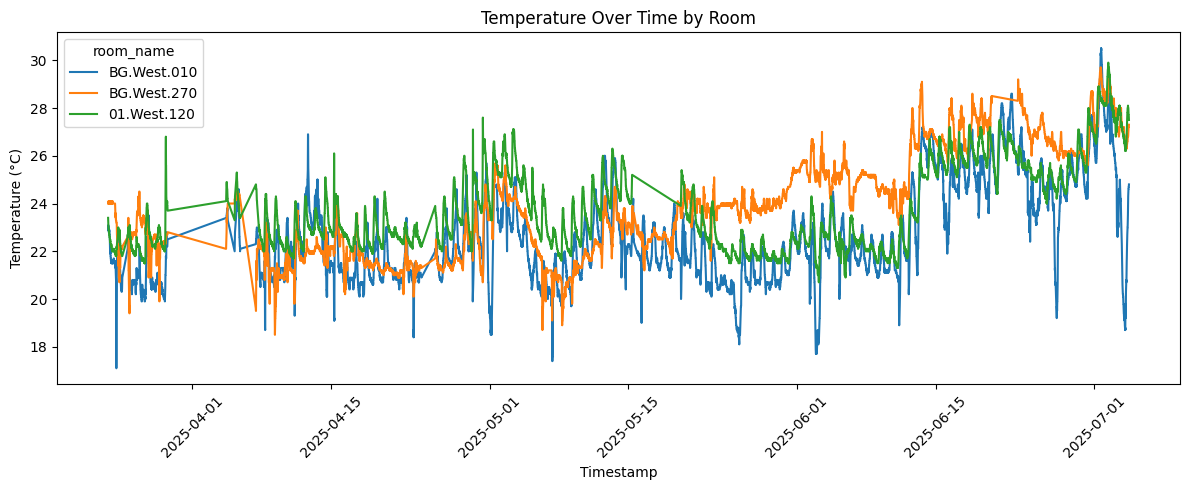

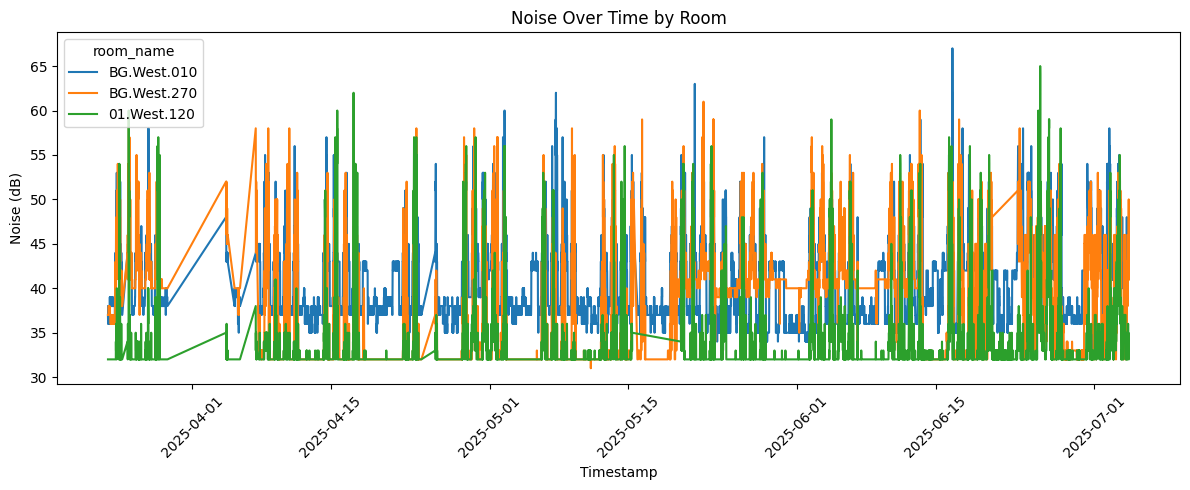

In [43]:
# BASIC DATA VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure datetime format
df_temp_cleaned.loc[:, "phenomenon_time"] = pd.to_datetime(df_temp_cleaned["phenomenon_time"])
df_noise_cleaned.loc[:, "phenomenon_time"] = pd.to_datetime(df_noise_cleaned["phenomenon_time"])

# --------- Statistical Summary ---------
print("Temperature Statistics:")
print(df_temp_cleaned.groupby("room_name")["internal_temp"].describe())

print("Noise Statistics:")
print(df_noise_cleaned.groupby("room_name")["noise"].describe())

# --------- Line Plot: Temperature Over Time ---------
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_temp_cleaned, x="phenomenon_time", y="internal_temp", hue="room_name")
plt.title("Temperature Over Time by Room")
plt.xlabel("Timestamp")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------- Line Plot: Noise Over Time ---------
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_noise_cleaned, x="phenomenon_time", y="noise", hue="room_name")
plt.title("Noise Over Time by Room")
plt.xlabel("Timestamp")
plt.ylabel("Noise (dB)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Issues revealed by first glance of data
The chart shows temperature over time for each room. As evident there is a lot of noise in the data and the size is too large to analyse (around 30000 temperature values)
This basic visualisation reveals two issues that need to be tacked - 
1. The time resolution (highest data resolution in terms of time is 10 minutes - based on sensor) needs to be reduced to 30 min, 45 min or 1 hr - selection of this resolution is to be based on the fact that temperature change should be somewhat significant in between two data entries - something like x times the standard deviation (where x<1)
2. Visualisation (chart) will give more insight if it shows a smaller date range (e.g. over a day or a week) instead of the entire 3 months of data being shown at once

#### Underneath codeblocks (two) attempt to tackle these issues by 
### 1. lowering time resolution of data 
and 2. visualising a smaller date range in a chart (dataframe would still have entire data for further analysis and processing)

In [44]:
# Selecting time resolution of data by - Calculating Mean Absolute Change for Different Time Intervals

# defining resampling intervals
intervals = ["10min", "30min", "45min", "1h"]
rooms = df_temp_cleaned["room_name"].unique()
# initialising result table
temp_summary = []
noise_summary = []
for interval in intervals:
    for room in rooms:
        # --- Temperature ---
        temp_room = df_temp_cleaned[df_temp_cleaned["room_name"] == room].copy() # Filter data for the specific room 
        temp_room = temp_room[["phenomenon_time", "internal_temp"]]  # keep only numeric column
        temp_room = temp_room.set_index("phenomenon_time").resample(interval).mean().dropna() # Sets timestamp as index so time-based operations can be performed. Then resamples the data to the specified interval and calculates the mean while ignoring bins with no data
        temp_room["diff"] = temp_room["internal_temp"].diff().abs() # Computes the absolute difference in temperature between consecutive time intervals
        mean_temp_change = temp_room["diff"].mean()
        temp_summary.append({ # Stores the mean change value, linked to its room and interval, in a summary table
            "room": room,
            "interval": interval,
            "mean_temp_change": round(mean_temp_change, 3)
        })

        # --- Noise ---
        noise_room = df_noise_cleaned[df_noise_cleaned["room_name"] == room].copy()
        noise_room = noise_room[["phenomenon_time", "noise"]]  # keep only numeric column
        noise_room = noise_room.set_index("phenomenon_time").resample(interval).mean().dropna()
        noise_room["diff"] = noise_room["noise"].diff().abs()
        mean_noise_change = noise_room["diff"].mean()
        noise_summary.append({
            "room": room,
            "interval": interval,
            "mean_noise_change": round(mean_noise_change, 3)
        })

# Convert to DataFrames for display
df_temp_change = pd.DataFrame(temp_summary)
df_noise_change = pd.DataFrame(noise_summary)

print("\nMean Temperature Change by Interval:")
print(df_temp_change.pivot(index="interval", columns="room", values="mean_temp_change"))

print("\nMean Noise Change by Interval:")
print(df_noise_change.pivot(index="interval", columns="room", values="mean_noise_change"))


Mean Temperature Change by Interval:
room      01.West.120  BG.West.010  BG.West.270
interval                                       
10min           0.042        0.065        0.051
1h              0.149        0.253        0.151
30min           0.085        0.146        0.095
45min           0.118        0.202        0.123

Mean Noise Change by Interval:
room      01.West.120  BG.West.010  BG.West.270
interval                                       
10min           0.705        0.692        0.924
1h              1.067        1.064        1.284
30min           0.883        0.826        1.013
45min           0.967        0.941        1.145


Based on these tables, avg temp change per hour (0.15-0.20 Celcius) is a decent granularity for now.

In [45]:
# ─── Create hourly-resampled dataframes ───
hourly_temp_frames = []
hourly_noise_frames = []
for room in rooms:
    # Temperature
    temp_room = df_temp_cleaned[df_temp_cleaned["room_name"] == room].copy()
    temp_room = temp_room[["phenomenon_time", "internal_temp"]]  # keep only numeric column
    temp_room = temp_room.set_index("phenomenon_time").resample("1h").mean().dropna().reset_index() # Sets "phenomenon_time" column as the index of the DataFrame - this is required before I can resample based on time. 
    # resample("1h") groups the data into 1-hour bins (i.e. creates a time-based “groupby”) before averaging each bin for each hour
    # reset_index() converts the datetime index back into a regular column so that phenomenon_time becomes a column again instead of the DataFrame index
    temp_room["room_name"] = room  # add back room info
    hourly_temp_frames.append(temp_room)

    # Noise
    noise_room = df_noise_cleaned[df_noise_cleaned["room_name"] == room].copy()
    noise_room = noise_room[["phenomenon_time", "noise"]]
    noise_room = noise_room.set_index("phenomenon_time").resample("1h").mean().dropna().reset_index()
    noise_room["room_name"] = room
    hourly_noise_frames.append(noise_room)

# Concatenate into new DataFrames
df_temp_hourly = pd.concat(hourly_temp_frames, ignore_index=True)
df_noise_hourly = pd.concat(hourly_noise_frames, ignore_index=True)

# Preview
print("\n✅ Hourly Temperature DataFrame:")
print(df_temp_hourly.head())

print("\n✅ Hourly Noise DataFrame:")
print(df_noise_hourly.head())



✅ Hourly Temperature DataFrame:
            phenomenon_time  internal_temp    room_name
0 2025-03-23 12:00:00+00:00      23.000000  BG.West.010
1 2025-03-23 13:00:00+00:00      22.966667  BG.West.010
2 2025-03-23 14:00:00+00:00      22.816667  BG.West.010
3 2025-03-23 15:00:00+00:00      22.766667  BG.West.010
4 2025-03-23 16:00:00+00:00      22.416667  BG.West.010

✅ Hourly Noise DataFrame:
            phenomenon_time      noise    room_name
0 2025-03-23 12:00:00+00:00  36.600000  BG.West.010
1 2025-03-23 13:00:00+00:00  36.666667  BG.West.010
2 2025-03-23 14:00:00+00:00  36.333333  BG.West.010
3 2025-03-23 15:00:00+00:00  36.500000  BG.West.010
4 2025-03-23 16:00:00+00:00  37.500000  BG.West.010


### 2. visualising a smaller date range in a chart 
(dataframe would still have entire data for further analysis and processing)

In [46]:
print(df_temp_hourly["phenomenon_time"].min())
print(df_temp_hourly["phenomenon_time"].max())

2025-03-23 12:00:00+00:00
2025-07-04 12:00:00+00:00


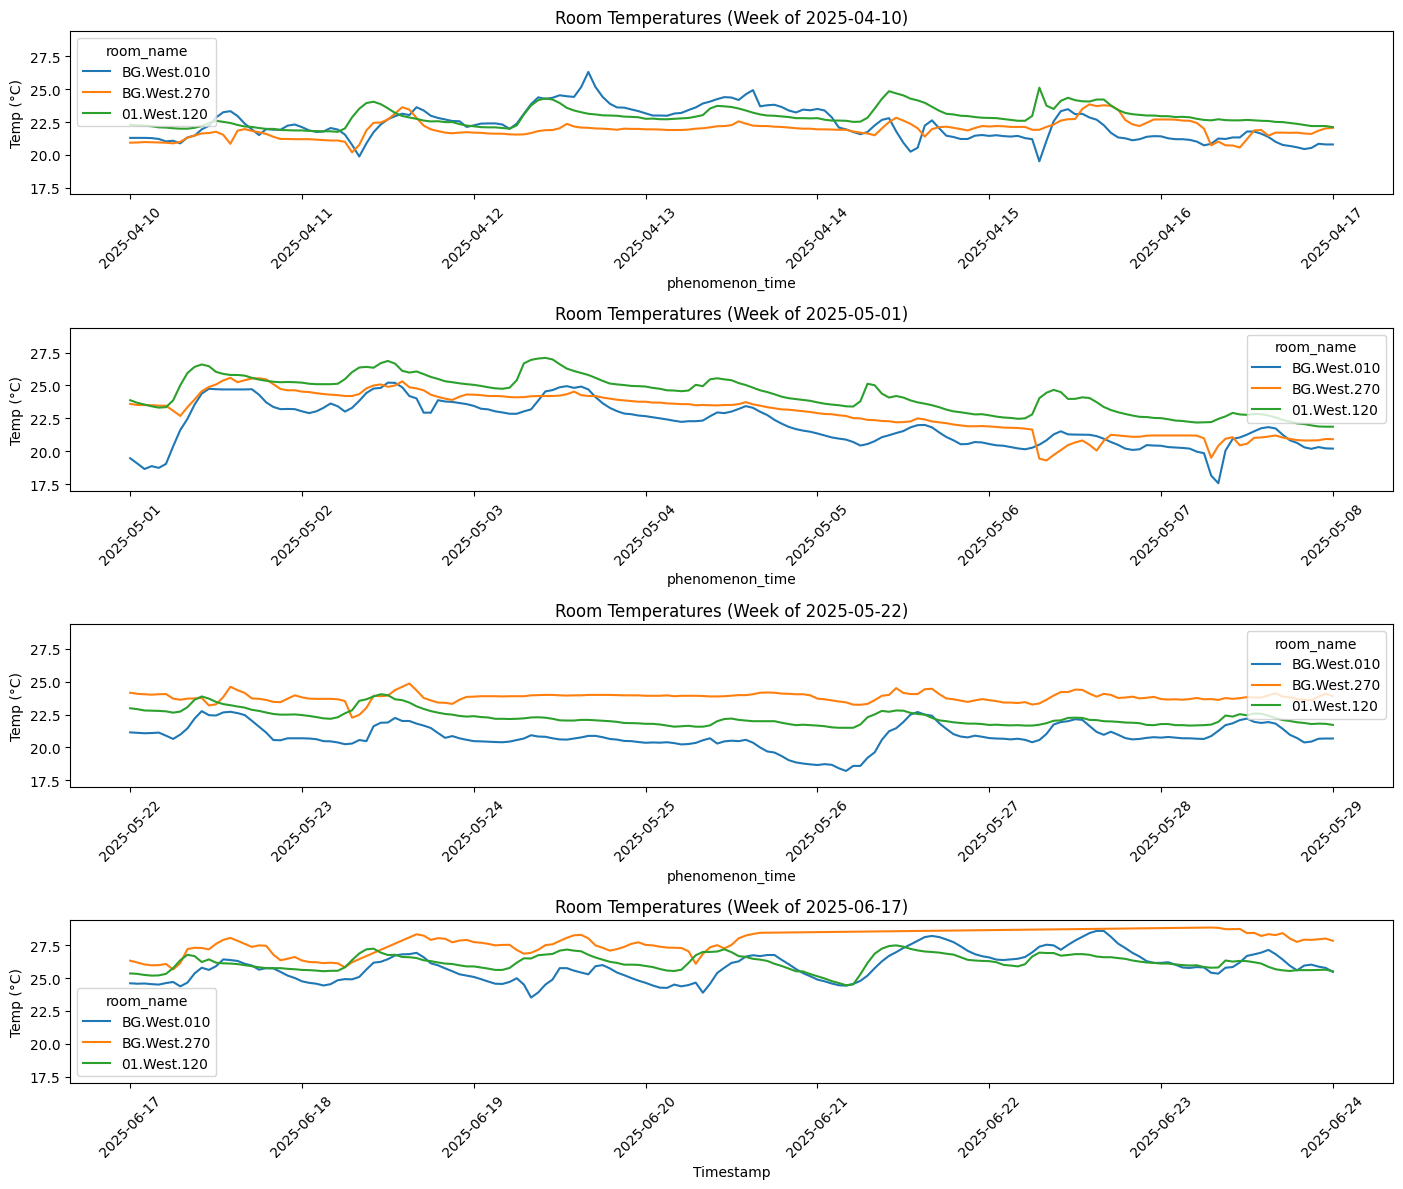

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure datetime is in correct format
df_temp_hourly["phenomenon_time"] = pd.to_datetime(df_temp_hourly["phenomenon_time"])

# ── Step 1: Define four weekly time ranges ──
week_ranges = [
    ("2025-04-10", "2025-04-17"),
    ("2025-05-01", "2025-05-08"),
    ("2025-05-22", "2025-05-29"),
    ("2025-06-17", "2025-06-24"),
]

# ── Step 2: Create subplots ──
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharey=True)

# ── Step 3: Filter and plot each week ──
for i, (start_date, end_date) in enumerate(week_ranges):
    week_data = df_temp_hourly[
        (df_temp_hourly["phenomenon_time"] >= start_date) &
        (df_temp_hourly["phenomenon_time"] <= end_date)
    ].copy()

    sns.lineplot(
        data=week_data,
        x="phenomenon_time",
        y="internal_temp",
        hue="room_name",
        ax=axes[i]
    )
    axes[i].set_title(f"Room Temperatures (Week of {start_date})")
    axes[i].set_ylabel("Temp (°C)")
    axes[i].tick_params(axis='x', rotation=45)

# ── Step 4: Label the final x-axis ──
axes[-1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

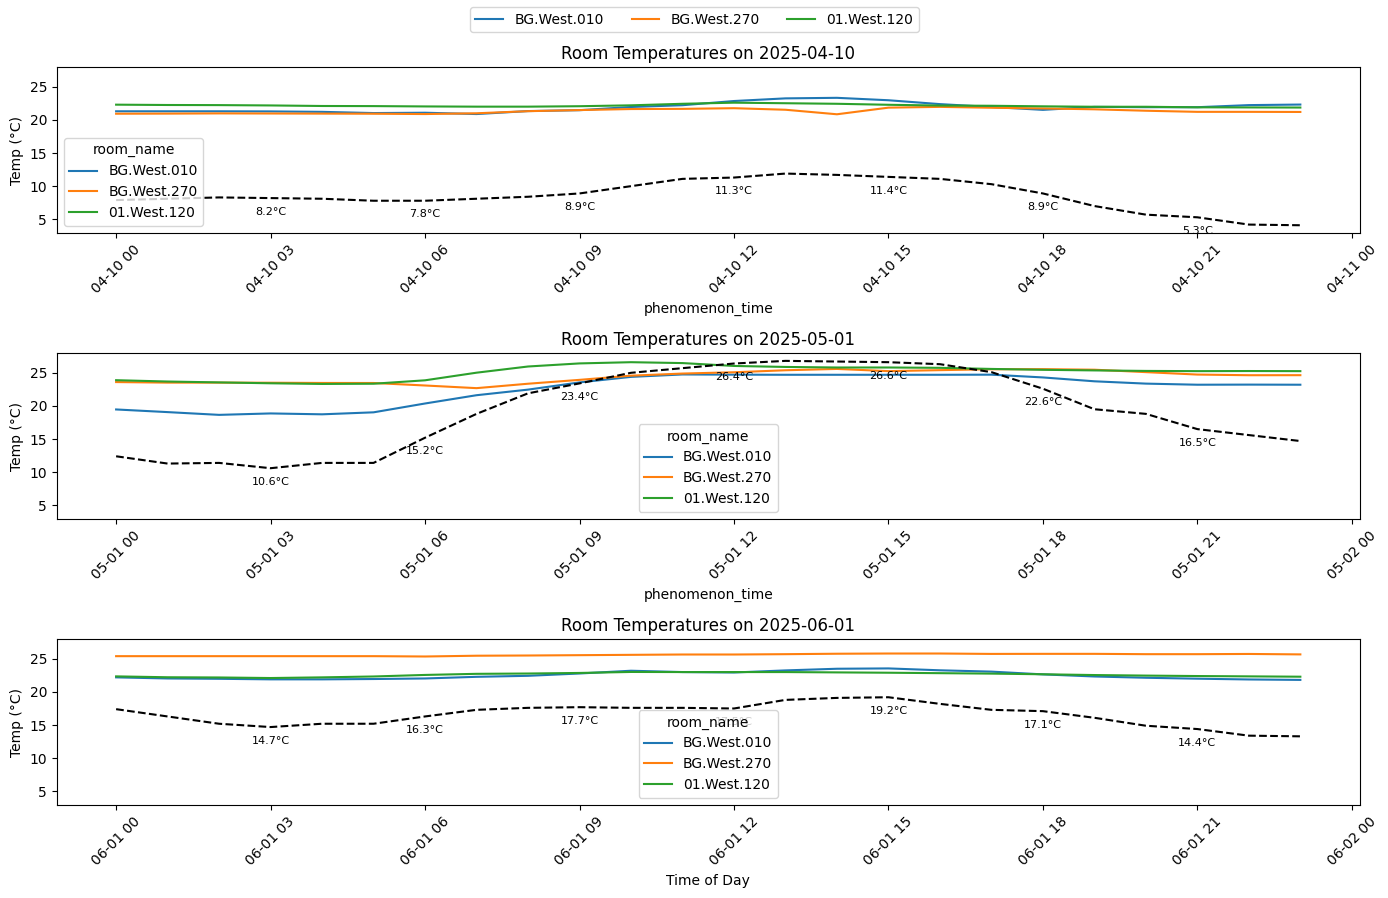

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from meteostat import Point, Hourly
from datetime import datetime

# TU Delft Bouwkunde coordinates - used for accessing external temperature data
bk_site = Point(52.0056, 4.3707, 0)
# Date range to fetch external temps (April to June)
start = datetime(2025, 4, 1)
end = datetime(2025, 6, 30)
# Fetch external hourly temperature
external_temp_combined = Hourly(bk_site, start, end).fetch()
external_temp_combined = external_temp_combined.reset_index()

# Keep only timestamp and temperature
external_temp_combined = external_temp_combined[["time", "temp"]]
external_temp_combined.columns = ["phenomenon_time", "external_temp"]
# Ensure datetime format
df_temp_hourly["phenomenon_time"] = pd.to_datetime(df_temp_hourly["phenomenon_time"])
external_temp_combined["phenomenon_time"] = pd.to_datetime(external_temp_combined["phenomenon_time"])

# ── Define target dates ──
target_dates = [
    ("2025-04-10", "2025-04-11"),
    ("2025-05-01", "2025-05-02"),
    ("2025-06-01", "2025-06-02"),
]

# ── Create subplots ──
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharey=True)

# ── Plot each date ──
for i, (start_date, end_date) in enumerate(target_dates):
    day_data = df_temp_hourly[
        (df_temp_hourly["phenomenon_time"] >= start_date) &
        (df_temp_hourly["phenomenon_time"] < end_date)
    ].copy()
    # Filter external temp data
    ext_data = external_temp_combined[
        (external_temp_combined["phenomenon_time"] >= start_date) &
        (external_temp_combined["phenomenon_time"] < end_date)
    ].copy()

    sns.lineplot(
        data=day_data,
        x="phenomenon_time",
        y="internal_temp",
        hue="room_name",
        ax=axes[i]
    )
    # Plot external temp (as a single dashed line)
    label = "External Temp" if i == 0 else None
    axes[i].plot(
        ext_data["phenomenon_time"],
        ext_data["external_temp"],
        color="black",
        linestyle="--",
        label=label
    )
    # adding external temperature values as labels for specific hours
    label_hours = [3, 6, 9, 12, 15, 18, 21]
    for hour in label_hours:
        label_time = pd.Timestamp(start_date) + pd.Timedelta(hours=hour)
        ext_point = ext_data[ext_data["phenomenon_time"] == label_time]
        if not ext_point.empty:
            y = ext_point["external_temp"].values[0]
            axes[i].annotate(
                f"{y:.1f}°C",
                xy=(label_time, y),
                xytext=(0, -12),  # shift label downward
                textcoords="offset points",
                fontsize=8,
                color="black",
                ha='center'
            )

    axes[i].set_title(f"Room Temperatures on {start_date}")
    axes[i].set_ylabel("Temp (°C)")
    axes[i].tick_params(axis='x', rotation=45)

# Add global legend (handles both hue and manual line)
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4)

axes[-1].set_xlabel("Time of Day")
plt.tight_layout(rect=[0, 0, 1, 0.97])  # Leave space for legend at top
plt.show()

#### Comparing external temperature readings with independent source
source link - https://weatherspark.com/h/d/51370/2025/4/10/Historical-Weather-on-Thursday-April-10-2025-in-Delft-Netherlands#Figures-Temperature
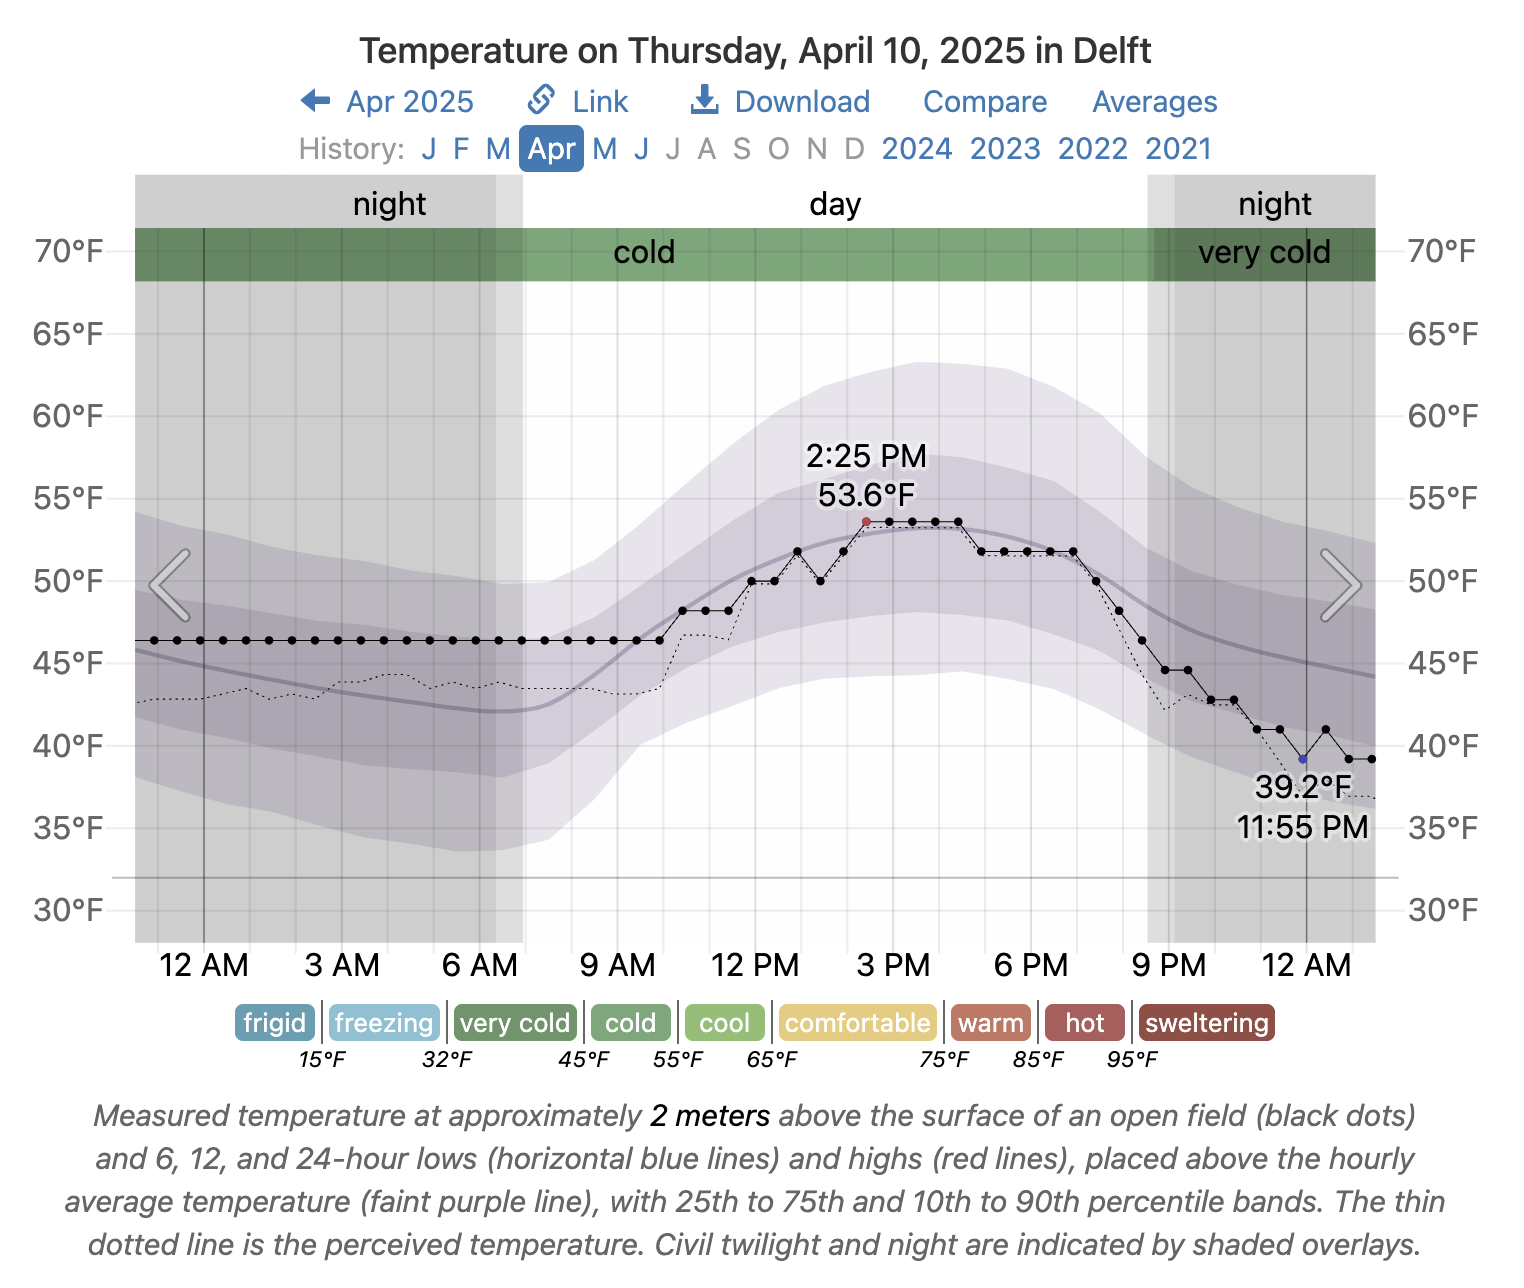

Readings from external source (weatherspark) in specific times on 4th April 2025: (in brackets - Meteostat API reading for that time - i.e. labels in charts above)
03:00 -> 46F = 7.77C (8.2C)
06:00 -> 46F = 7.77C (7.8C)
09:00 -> 46F = 7.77C (8.9C)
12:00 -> 50F = 10.0C (11.3C)
15:00 -> 54F = 12.22C (11.4C)
18:00 -> 52F = 11.11C (8.9C)
21:00 -> 45F = 7.22C (5.3C)

Analysis - the external temp readings of the two sources are quite different. This could be because the nearest meteostat reader from BK is located in Rotterdam. Need to look for better API source - Netatmo


In [49]:
from meteostat import Stations

stations = Stations()
stations = stations.nearby(52.0056, 4.3707)
print(stations.fetch(3))

                                 name country region    wmo  icao  latitude  \
id                                                                            
06344  Rotterdam Airport Zestienhoven      NL     ZH  06344  EHRD   51.9500   
06343         Rotterdam Geulhaven Aws      NL     ZH  06343  <NA>   51.8833   
06330                Hoek Van Holland      NL     ZH  06330  <NA>   51.9833   

       longitude  elevation          timezone hourly_start hourly_end  \
id                                                                      
06344     4.4500       -5.0  Europe/Amsterdam   1957-01-01 2025-06-28   
06343     4.3167        4.0  Europe/Amsterdam   1994-09-01 2025-06-03   
06330     4.1000        7.0  Europe/Amsterdam   1949-02-14 2025-06-03   

      daily_start  daily_end monthly_start monthly_end      distance  
id                                                                    
06344  1973-01-02 2022-04-25    1977-01-01  2022-01-01   8229.406001  
06343         NaT        

Hence proved - no meteostat station in delft
Netatmo public API - limitation - no historical data, only recent readings
Open-Meteo API - Provides hourly historical data, including temperature

In [53]:
# Trying Open-Meteo API
import requests
import pandas as pd
from datetime import datetime

# ── Delft Bouwkunde coordinates ──
latitude = 52.0056
longitude = 4.3707
start_date = "2025-04-01"
end_date = "2025-06-30"

# ── Open-Meteo Archive API Endpoint ──
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": "temperature_2m",
    "timezone": "auto"
}

# ── Make request ──
response = requests.get(url, params=params)
data = response.json()

# ── Convert to DataFrame with same structure as Meteostat output ──
external_temp_combined = pd.DataFrame({
    "phenomenon_time": pd.to_datetime(data["hourly"]["time"]),
    "external_temp": data["hourly"]["temperature_2m"]
})
ext_data = external_temp_combined[
    (external_temp_combined["phenomenon_time"] >= start_date) &
    (external_temp_combined["phenomenon_time"] < end_date)
].copy()
print(external_temp_combined.head())
# ── Save to CSV ──
external_temp_combined.to_csv("external_temp_openmeteo_delft_2025_Apr_to_Jun.csv", index=False)
print("Saved to external_temp_openmeteo_delft_2025_Apr_to_Jun.csv")

      phenomenon_time  external_temp
0 2025-04-01 00:00:00            4.1
1 2025-04-01 01:00:00            3.4
2 2025-04-01 02:00:00            3.0
3 2025-04-01 03:00:00            2.4
4 2025-04-01 04:00:00            2.2
Saved to external_temp_openmeteo_delft_2025_Apr_to_Jun.csv


All three sources have quite varying values:
3 sources - 
1. Weatherspark website (https://weatherspark.com/h/d/51370/2025/4/10/Historical-Weather-on-Thursday-April-10-2025-in-Delft-Netherlands#Figures-Temperature) 
2. Meteostat API and 
3. Open-Meteo API
Source 2 has reading from Rotterdam so I understand why it might be different, but 1 and 3 should have been similar.



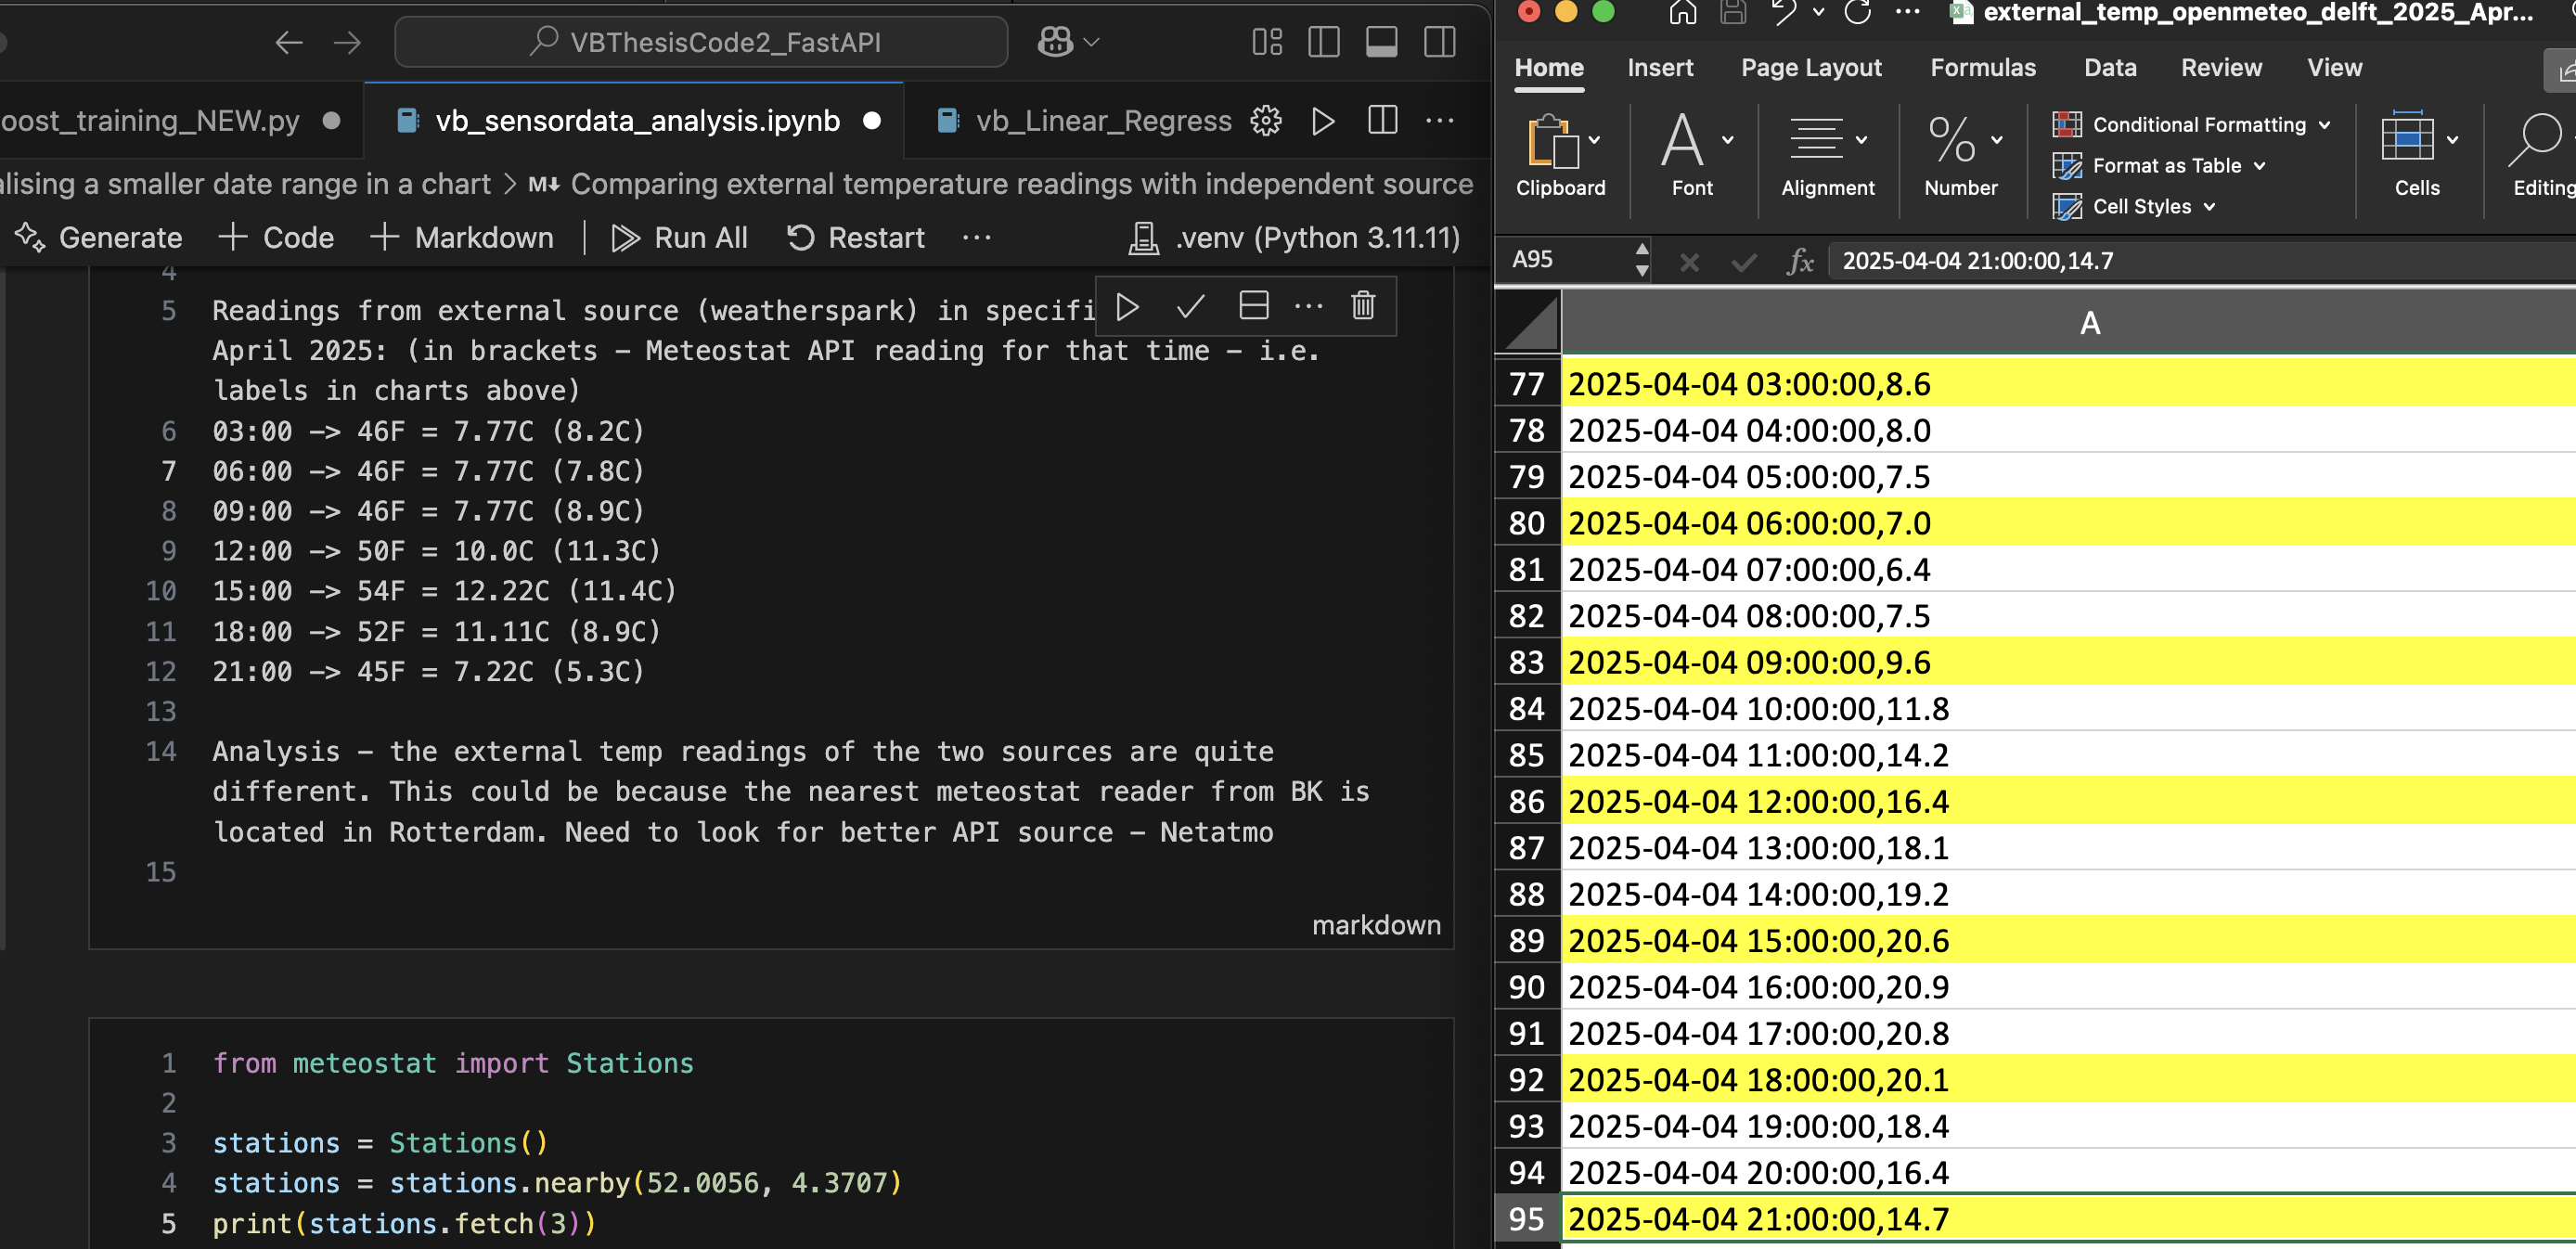


Realisation - source 3 (Open-Meteo) - not actual sensor data — simulated based on global physics + satellite assimilation
Summary from other potential sources for external temp sources: 
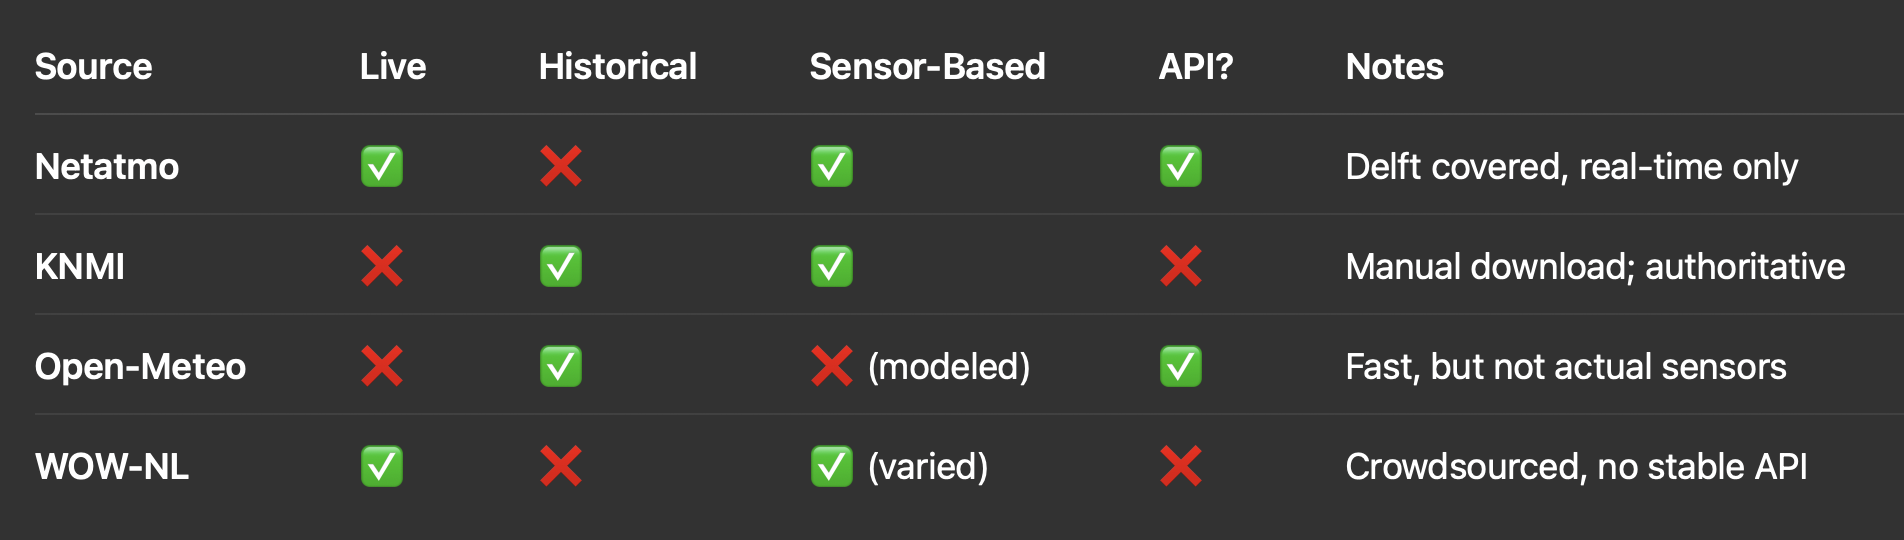

#### KNMI Resources
different datasets curated and published by KNMI:
Each listing represents a different temperature-related dataset offered by KNMI, Some are raw, some are validated, some are reprocessed.
ISSUE - These are access bound - requires specical permission (key) from KNMI

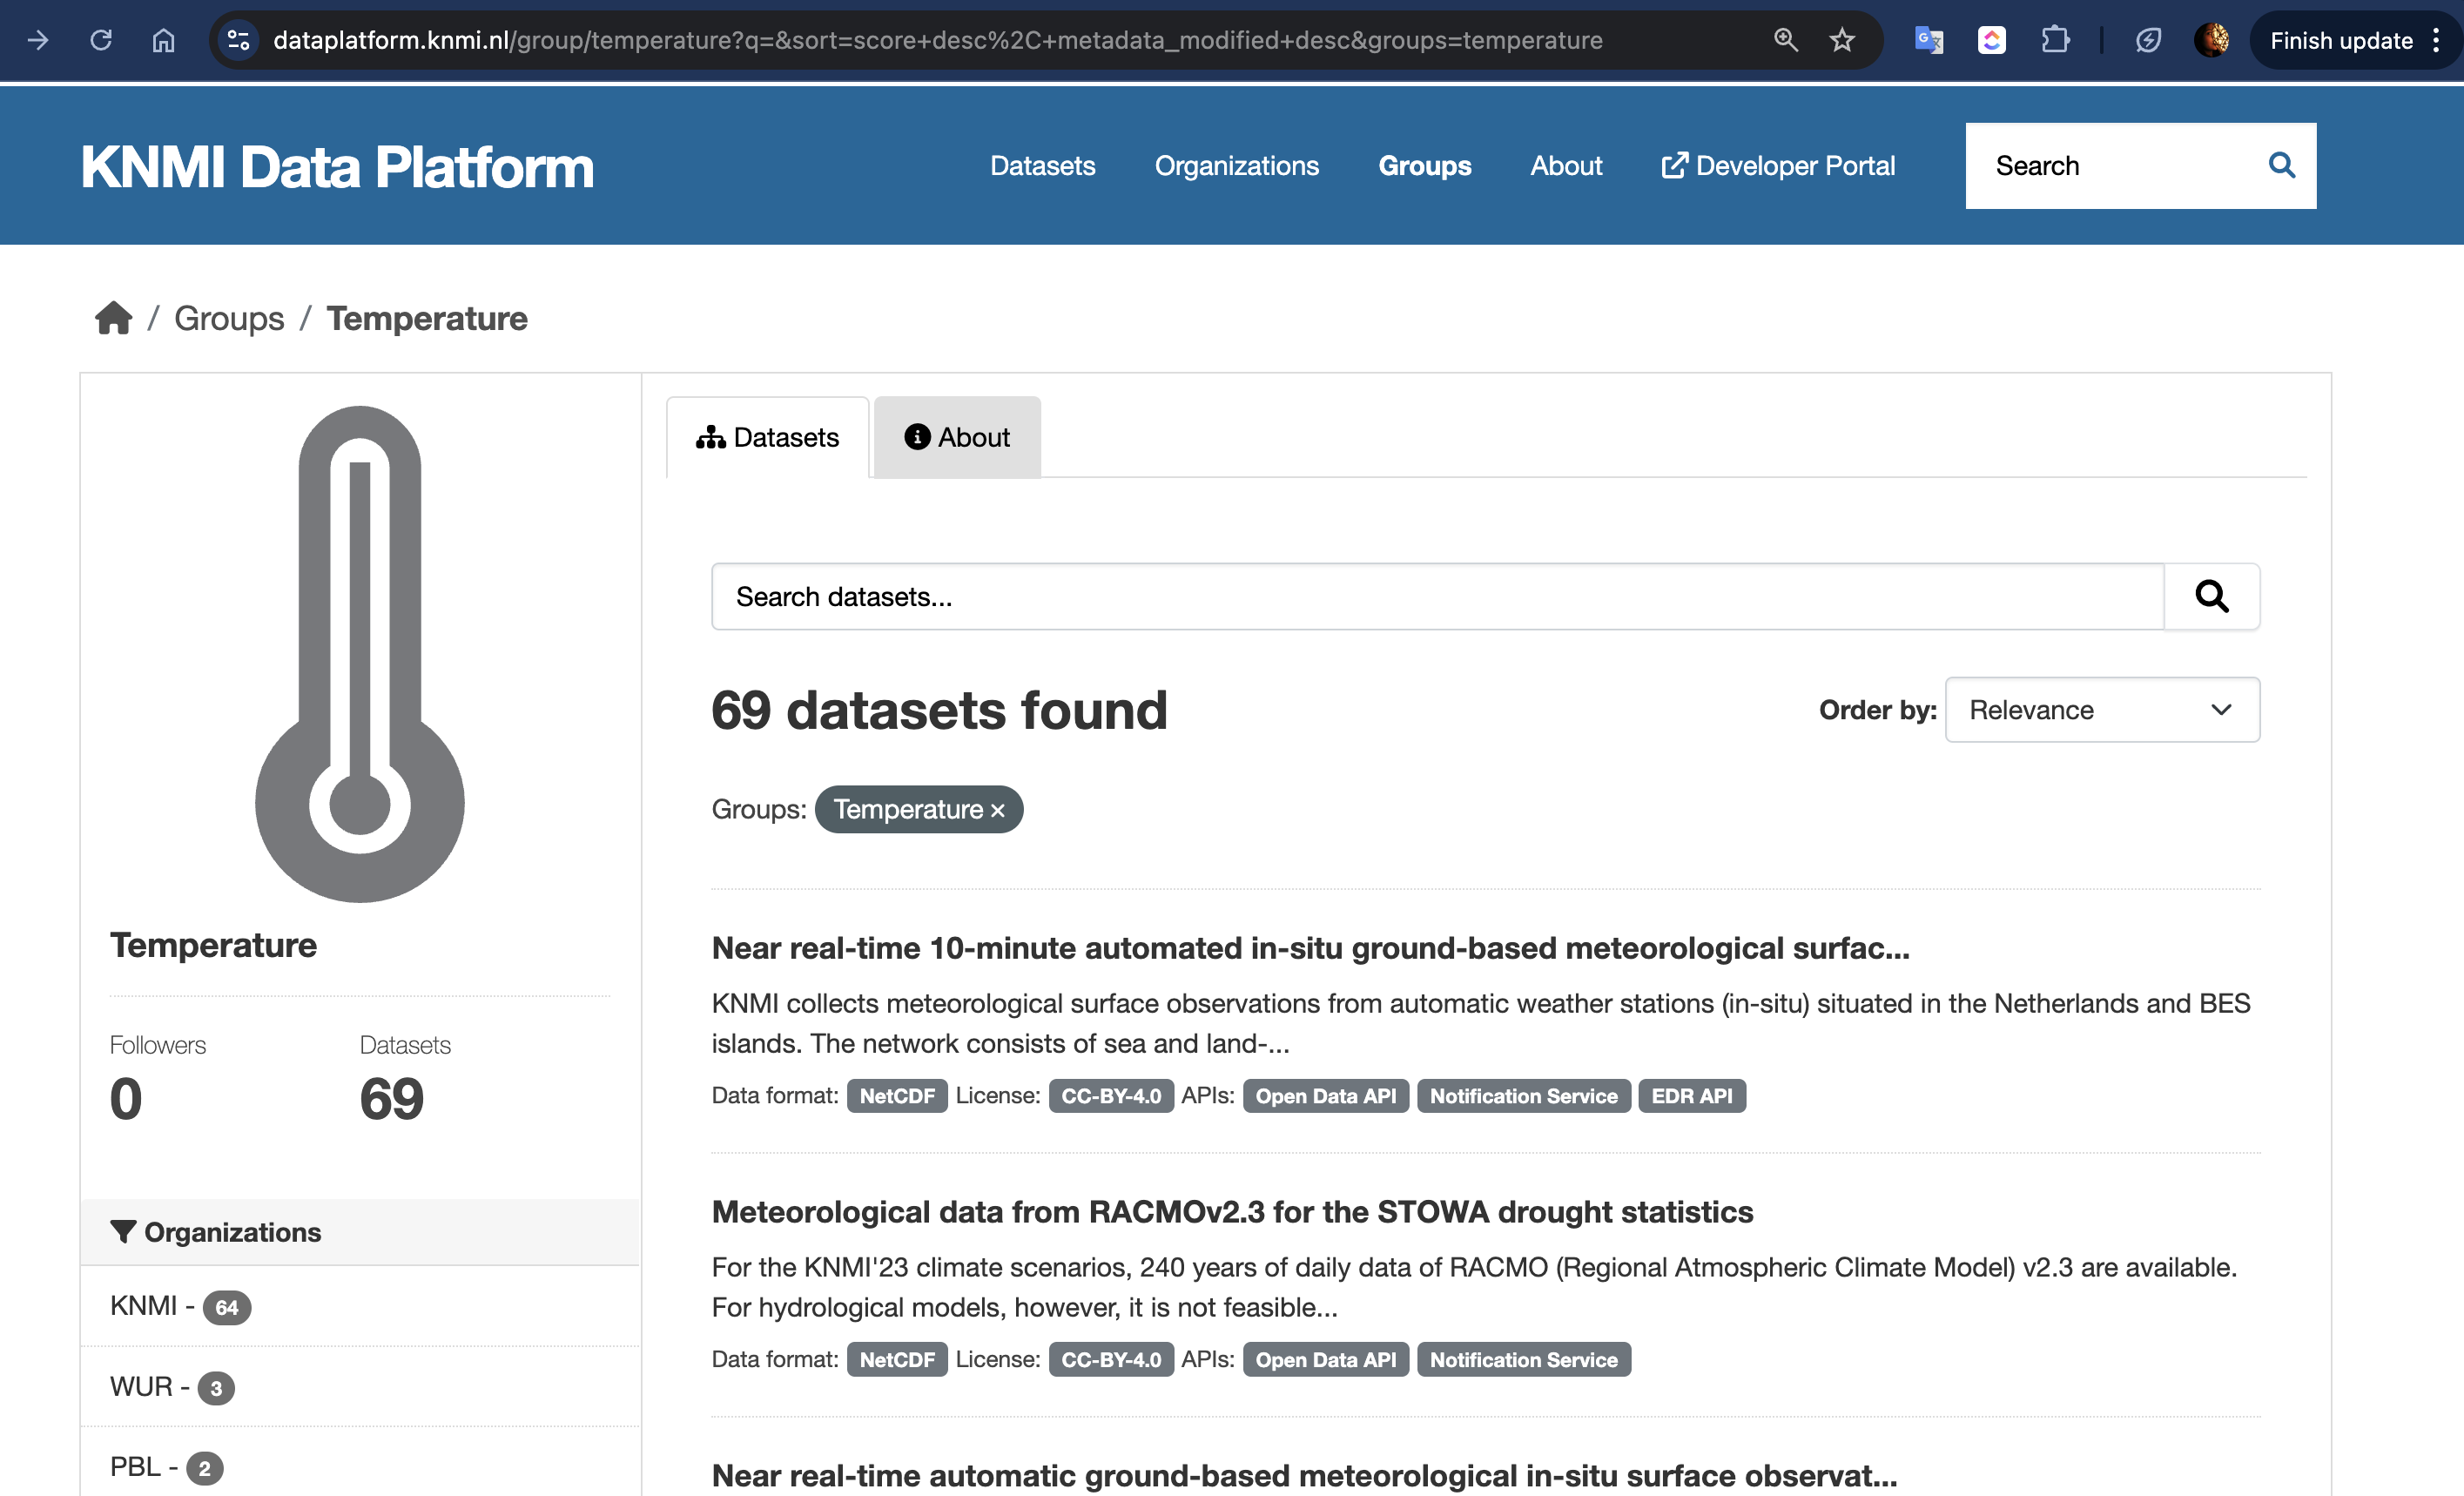


### Pulse.eco 
https://delft.pulse.eco/ is a crowdsourced environmental sensing platform that includes Temperature and Air quality data from sensors. Pulse.eco explicitly offers a REST API, "One of the main project features is to make the data available to everyone. Feel free to use our API and gather the data for the development of your own applications.” Only con - Accuracy is not guaranteed as data depends on third-party or DIY sensors
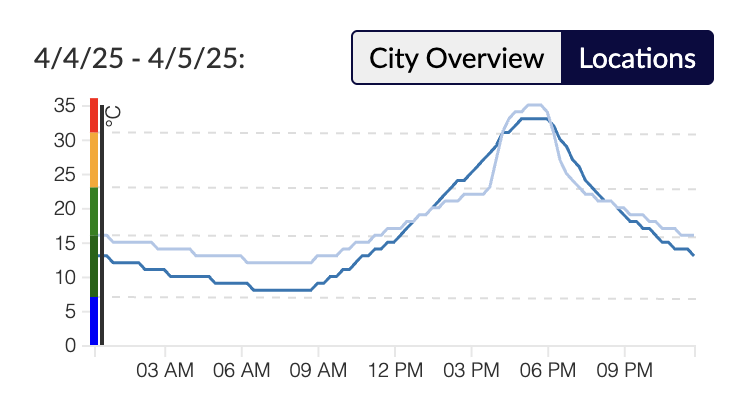


Comparing the four sources of external temperature data for random selected date (10th April 2025): 
1. weatherspark - websource, no API, Delft readings
2. Meteostat API - API, nearest sensor in Rotterdam
3. Open-Meteo - simulated temperature data based on global physics + satellite assimilation
4. Pulse.eco - API, opensource, Delft readings

| Time (CET) | Weatherspark (°C) | Meteostat API (°C)      | Open-Meteo API (°C)                                   | Pulse.eco (°C)             |
|------------|--------------------|--------------------------|--------------------------------------------------------|-----------------------------|
|            | Websource, no API, Delft readings | API, nearest sensor in Rotterdam | Simulated data from global models + satellite assimilation | API, open-source, Delft readings |
| 03:00      | 7.77               | 8.2                      | 8.6                                                    | 13                          |
| 06:00      | 7.77               | 7.8                      | 7.0                                                    | 11                          |
| 09:00      | 7.77               | 8.9                      | 9.6                                                    | 11                          |
| 12:00      | 10.0               | 11.3                     | 16.4                                                   | 16                          |
| 15:00      | 12.22              | 11.4                     | 20.6                                                   | 24                          |
| 18:00      | 11.11              | 8.9                      | 20.1                                                   | 33                          |
| 21:00      | 7.22               | 5.3                      | 14.7                                                   | 19                          |


There are other website data too (e.g. https://www.weather25.com/europe/netherlands/zuid-holland/delft?page=past-weather#day=4&month=4) but this too isn't consistent with any of the above

Google map - weather API

## Internal Temperature Data Analysis

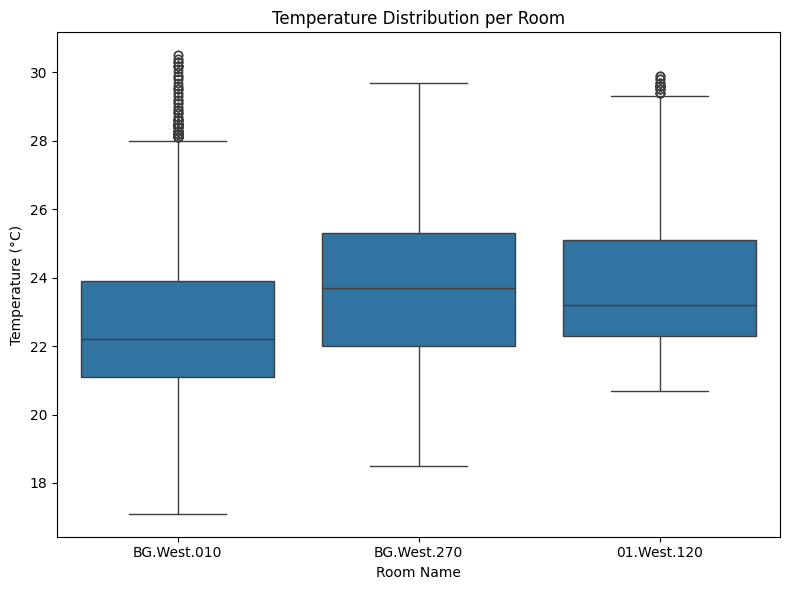

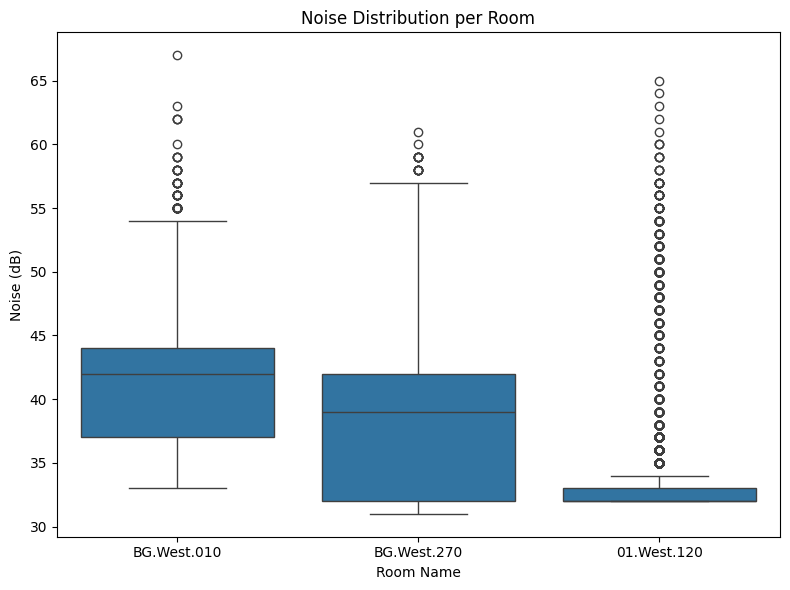

In [50]:

# --------- Boxplot: Temperature Distribution ---------
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_temp_cleaned, x="room_name", y="internal_temp")
plt.title("Temperature Distribution per Room")
plt.xlabel("Room Name")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

# --------- Boxplot: Noise Distribution ---------
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_noise_cleaned, x="room_name", y="noise")
plt.title("Noise Distribution per Room")
plt.xlabel("Room Name")
plt.ylabel("Noise (dB)")
plt.tight_layout()
plt.show()


### BoxPlot analysis:
Theoretical: For each room (on X-axis), the plot shows the spread of internal temperature values (on Y-axis). The box shows where the “bulk” of the temperatures are - 50% of datapoints (IQR (Interquartile Range) = Q3 - Q1) are inside the box range, 25% below the bottom and 25% above. The line inside each box indicates the median value. Any dots above or below the whiskers are outliers — unusually high or low readings compared to the rest of data.

### Linear Regression
Herein I am tracing linear correlation between external temperature and internal temperature in the rooms individually wherein:
Independent variable (X): External temperature
Dependent variable (Y): Internal room temperature

In [51]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt